In [2]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

### Learn OpenF1

In [17]:
from urllib.request import urlopen
import json

In [19]:
response = urlopen('https://api.openf1.org/v1/car_data?driver_number=55&session_key=9159&speed>=315')
data = json.loads(response.read().decode('utf-8'))
pd.DataFrame(data)

,date,session_key,meeting_key,driver_number,n_gear,speed,drs,throttle,brake,rpm
0,2023-09-15T13:08:19.923000+00:00,9159,1219,55,8,315,12,99,0,11141
1,2023-09-15T13:35:41.808000+00:00,9159,1219,55,8,315,8,57,100,11023


### Learn FastF1

In [3]:
import fastf1

In [21]:
schedule = fastf1.get_event_schedule(2026)
schedule.columns

Index(['RoundNumber', 'Country', 'Location', 'OfficialEventName', 'EventDate',
       'EventName', 'EventFormat', 'Session1', 'Session1Date',
       'Session1DateUtc', 'Session2', 'Session2Date', 'Session2DateUtc',
       'Session3', 'Session3Date', 'Session3DateUtc', 'Session4',
       'Session4Date', 'Session4DateUtc', 'Session5', 'Session5Date',
       'Session5DateUtc', 'F1ApiSupport'],
      dtype='object')

In [4]:
race = fastf1.get_session(2026, 'Japan', 'R')
race.load()

req         WARNING 	DEFAULT CACHE ENABLED! (231.93 MB) /home/chrischu/.cache/fastf1
core           INFO 	Loading data for Japanese Grand Prix - Race [v3.6.1]
req            INFO 	Using cached data for session_info
req            INFO 	Using cached data for driver_info
req            INFO 	Using cached data for session_status_data
req            INFO 	Using cached data for lap_count
req            INFO 	Using cached data for track_status_data
req            INFO 	Using cached data for _extended_timing_data
req            INFO 	Using cached data for timing_app_data
core           INFO 	Processing timing data...
req            INFO 	No cached data found for car_data. Loading data...
_api           INFO 	Fetching car data...
_api           INFO 	Parsing car data...
logger      WARNING 	Failed to load telemetry data!
req            INFO 	Using cached data for weather_data
req            INFO 	Using cached data for race_control_messages
core           INFO 	Finished loading data for 22 driv

In [5]:
race_name = race.session_info['Meeting']['Name']
race_year = race.session_info['StartDate'].year
race_round = race.session_info['Meeting']['Number']
print(f"{race_name} {race_year} - Round {race_round}")

Japanese Grand Prix 2026 - Round 3


In [61]:
race.results

,DriverNumber,BroadcastName,Abbreviation,DriverId,TeamName,TeamColor,TeamId,FirstName,LastName,FullName,...,Position,ClassifiedPosition,GridPosition,Q1,Q2,Q3,Time,Status,Points,Laps
12,12,K ANTONELLI,ANT,antonelli,Mercedes,00D7B6,mercedes,Kimi,Antonelli,Kimi Antonelli,...,1.0,1,1.0,NaT,NaT,NaT,0 days 01:28:03.403000,Finished,25.0,53.0
81,81,O PIASTRI,PIA,piastri,McLaren,F47600,mclaren,Oscar,Piastri,Oscar Piastri,...,2.0,2,3.0,NaT,NaT,NaT,0 days 00:00:13.722000,Finished,18.0,53.0
16,16,C LECLERC,LEC,leclerc,Ferrari,ED1131,ferrari,Charles,Leclerc,Charles Leclerc,...,3.0,3,4.0,NaT,NaT,NaT,0 days 00:00:15.270000,Finished,15.0,53.0
63,63,G RUSSELL,RUS,russell,Mercedes,00D7B6,mercedes,George,Russell,George Russell,...,4.0,4,2.0,NaT,NaT,NaT,0 days 00:00:15.754000,Finished,12.0,53.0
1,1,L NORRIS,NOR,norris,McLaren,F47600,mclaren,Lando,Norris,Lando Norris,...,5.0,5,5.0,NaT,NaT,NaT,0 days 00:00:23.479000,Finished,10.0,53.0
44,44,L HAMILTON,HAM,hamilton,Ferrari,ED1131,ferrari,Lewis,Hamilton,Lewis Hamilton,...,6.0,6,6.0,NaT,NaT,NaT,0 days 00:00:25.037000,Finished,8.0,53.0
10,10,P GASLY,GAS,gasly,Alpine,00A1E8,alpine,Pierre,Gasly,Pierre Gasly,...,7.0,7,7.0,NaT,NaT,NaT,0 days 00:00:32.340000,Finished,6.0,53.0
3,3,M VERSTAPPEN,VER,max_verstappen,Red Bull Racing,4781D7,red_bull,Max,Verstappen,Max Verstappen,...,8.0,8,11.0,NaT,NaT,NaT,0 days 00:00:32.677000,Finished,4.0,53.0
30,30,L LAWSON,LAW,lawson,Racing Bulls,6C98FF,rb,Liam,Lawson,Liam Lawson,...,9.0,9,14.0,NaT,NaT,NaT,0 days 00:00:50.180000,Finished,2.0,53.0
31,31,E OCON,OCO,ocon,Haas F1 Team,9C9FA2,haas,Esteban,Ocon,Esteban Ocon,...,10.0,10,12.0,NaT,NaT,NaT,0 days 00:00:51.216000,Finished,1.0,53.0


In [28]:
race.laps.columns

Index(['Time', 'Driver', 'DriverNumber', 'LapTime', 'LapNumber', 'Stint',
       'PitOutTime', 'PitInTime', 'Sector1Time', 'Sector2Time', 'Sector3Time',
       'Sector1SessionTime', 'Sector2SessionTime', 'Sector3SessionTime',
       'SpeedI1', 'SpeedI2', 'SpeedFL', 'SpeedST', 'IsPersonalBest',
       'Compound', 'TyreLife', 'FreshTyre', 'Team', 'LapStartTime',
       'LapStartDate', 'TrackStatus', 'Position', 'Deleted', 'DeletedReason',
       'FastF1Generated', 'IsAccurate'],
      dtype='object')

In [27]:
race.laps

,Time,Driver,DriverNumber,LapTime,LapNumber,Stint,PitOutTime,PitInTime,Sector1Time,Sector2Time,...,FreshTyre,Team,LapStartTime,LapStartDate,TrackStatus,Position,Deleted,DeletedReason,FastF1Generated,IsAccurate
0,0 days 01:05:22.170000,NOR,1,0 days 00:01:37.206000,1.0,1.0,NaT,NaT,NaT,0 days 00:00:42.011000,...,True,McLaren,0 days 01:03:44.711000,NaT,1,3.0,False,,False,False
1,0 days 01:06:57.075000,NOR,1,0 days 00:01:34.905000,2.0,1.0,NaT,NaT,0 days 00:00:34.856000,0 days 00:00:42.120000,...,True,McLaren,0 days 01:05:22.170000,NaT,1,3.0,False,,False,True
2,0 days 01:08:33.376000,NOR,1,0 days 00:01:36.301000,3.0,1.0,NaT,NaT,0 days 00:00:36.026000,0 days 00:00:42.108000,...,True,McLaren,0 days 01:06:57.075000,NaT,1,4.0,False,,False,True
3,0 days 01:10:08.827000,NOR,1,0 days 00:01:35.451000,4.0,1.0,NaT,NaT,0 days 00:00:35.147000,0 days 00:00:42.190000,...,True,McLaren,0 days 01:08:33.376000,NaT,1,4.0,False,,False,True
4,0 days 01:11:43.997000,NOR,1,0 days 00:01:35.170000,5.0,1.0,NaT,NaT,0 days 00:00:34.925000,0 days 00:00:42.206000,...,True,McLaren,0 days 01:10:08.827000,NaT,1,4.0,False,,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1102,0 days 01:31:41.771000,BEA,87,0 days 00:01:57.448000,17.0,2.0,0 days 01:30:08.107000,NaT,0 days 00:00:57.139000,0 days 00:00:41.840000,...,True,Haas F1 Team,0 days 01:29:44.323000,NaT,1,19.0,False,,False,False
1103,0 days 01:33:17.825000,BEA,87,0 days 00:01:36.054000,18.0,2.0,NaT,NaT,0 days 00:00:35.006000,0 days 00:00:42.424000,...,True,Haas F1 Team,0 days 01:31:41.771000,NaT,1,19.0,False,,False,True
1104,0 days 01:34:53.730000,BEA,87,0 days 00:01:35.905000,19.0,2.0,NaT,NaT,0 days 00:00:35.345000,0 days 00:00:42.252000,...,True,Haas F1 Team,0 days 01:33:17.825000,NaT,1,18.0,False,,False,True
1105,0 days 01:36:29.334000,BEA,87,0 days 00:01:35.604000,20.0,2.0,NaT,NaT,0 days 00:00:35.253000,0 days 00:00:42.310000,...,True,Haas F1 Team,0 days 01:34:53.730000,NaT,1,18.0,False,,False,True


In [6]:
lap_numbers = race.laps['LapNumber'].unique()
driver_numbers = race.laps['DriverNumber'].unique()

##### Plot Race Trace

In [7]:
# Get the average pace for each lap
# Average every driver's lap end time, don't count laps without LapTime
lap_pace = []
for n in lap_numbers:
    avg_time = 0.0
    paces = []
    count = 0
    for d in driver_numbers:
        lap_data = race.laps[(race.laps['LapNumber'] == n) & (race.laps['DriverNumber'] == d)]
        if not lap_data.empty and lap_data['LapStartTime'].iloc[0] is not pd.NaT:
            #avg_time += lap_data['Time'].iloc[0].total_seconds()
            paces.append(lap_data['Time'].iloc[0].total_seconds())
            count += 1
    if count > 0:
        #lap_pace.append(avg_time / count)
        lap_pace.append(np.median(paces))
print(len(lap_pace))

53


In [8]:
# A list of each driver's time offset from the average pace for each lap
driver_offsets = {d: [] for d in driver_numbers}
for n in lap_numbers:
    ind = int(n) - 1
    avg_time = lap_pace[ind]  # Lap numbers start at 1
    for d in driver_numbers:
        lap_data = race.laps[(race.laps['LapNumber'] == n) & (race.laps['DriverNumber'] == d)]
        if not lap_data.empty and lap_data['LapStartTime'].iloc[0] is not pd.NaT:
            driver_time = lap_data['Time'].iloc[0].total_seconds()
            driver_offsets[d].append(avg_time - driver_time) # positive means faster than average
        else:
            driver_offsets[d].append(np.nan)
print(driver_offsets)

{'1': [4.999499999999898, 6.936000000000149, 7.739999999999782, 8.558500000000095, 9.759999999999309, 11.86450000000059, 13.30200000000059, 14.37249999999949, 15.267499999999927, 16.465500000000247, 16.99200000000019, 19.50999999999931, 21.1875, 22.690999999999804, 24.1274999999996, 22.918499999999767, 5.289999999999964, 7.768000000000029, 10.662000000000262, 17.00500000000011, 19.061000000000604, 21.309000000000196, 27.293000000000575, 5.8659999999999854, 5.609000000000378, 6.7409999999999854, 2.311000000000604, 3.70299999999952, 5.997000000000298, 7.670000000000073, 7.144000000000233, 7.554000000000087, 8.560999999999694, 10.0, 11.743999999999687, 12.84099999999944, 13.986499999999978, 15.203500000000531, 15.977500000000873, 17.20550000000003, 18.442000000000007, 19.462999999999738, 20.40350000000035, 21.71349999999802, 23.63299999999981, 25.644500000000335, 26.602500000000873, 26.40899999999965, 27.394500000000335, 27.730500000001484, 26.96849999999904, 27.063000000000102, 26.680000

In [9]:
# A list of each driver's pit laps
driver_pit_laps = {d: [] for d in driver_numbers}
for d in driver_numbers:
    for n in lap_numbers:
        lap_data = race.laps[(race.laps['LapNumber'] == n) & (race.laps['DriverNumber'] == d)]
        if not lap_data.empty and lap_data['LapStartTime'].iloc[0] is not pd.NaT:
            if lap_data['PitInTime'].iloc[0] is not pd.NaT:
                driver_pit_laps[d].append(int(n))
print(driver_pit_laps)

{'1': [16], '10': [22], '11': [21], '12': [22], '14': [21, 23], '16': [17], '18': [21, 24, 30], '23': [22, 45, 46, 47, 48, 49], '27': [23], '3': [22], '30': [22], '31': [19], '41': [18], '43': [17], '44': [22], '5': [22], '55': [22], '6': [19], '63': [21], '77': [19], '81': [18], '87': [16]}


In [10]:
# Last name, team color, and driver number for each driver
driver_info = {}
team_repeat = []
for d in driver_numbers:
    driver_data = race.results[race.results['DriverNumber'] == d]
    if not driver_data.empty:
        last_name = driver_data['LastName'].iloc[0]
        position = int(driver_data['Position'].iloc[0])
        team_color = driver_data['TeamColor'].iloc[0]
        # use different line style for teammates
        if team_color in team_repeat:
            plot_linestyle = '-.'
        else:
            plot_linestyle = '-'
            team_repeat.append(team_color)
        driver_info[d] = (last_name, position, team_color, plot_linestyle)
print(driver_info)

{'1': ('Norris', 5, 'F47600', '-'), '10': ('Gasly', 7, '00A1E8', '-'), '11': ('Perez', 17, '909090', '-'), '12': ('Antonelli', 1, '00D7B6', '-'), '14': ('Alonso', 18, '229971', '-'), '16': ('Leclerc', 3, 'ED1131', '-'), '18': ('Stroll', 21, '229971', '-.'), '23': ('Albon', 20, '1868DB', '-'), '27': ('Hulkenberg', 11, 'F50537', '-'), '3': ('Verstappen', 8, '4781D7', '-'), '30': ('Lawson', 9, '6C98FF', '-'), '31': ('Ocon', 10, '9C9FA2', '-'), '41': ('Lindblad', 14, '6C98FF', '-.'), '43': ('Colapinto', 16, '00A1E8', '-.'), '44': ('Hamilton', 6, 'ED1131', '-.'), '5': ('Bortoleto', 13, 'F50537', '-.'), '55': ('Sainz', 15, '1868DB', '-.'), '6': ('Hadjar', 12, '4781D7', '-.'), '63': ('Russell', 4, '00D7B6', '-.'), '77': ('Bottas', 19, '909090', '-.'), '81': ('Piastri', 2, 'F47600', '-.'), '87': ('Bearman', 22, '9C9FA2', '-.')}


In [11]:
# Safety car periods
safety_car_lap_numbers = []
for status in race.laps['TrackStatus'].dropna().unique():
    if '4' in status:
        laps_with_status = race.laps[race.laps['TrackStatus'] == status]
        safety_car_lap_numbers.extend(laps_with_status['LapNumber'].unique())
safety_car_lap_numbers = sorted(set(safety_car_lap_numbers))
safety_car_lap_numbers = safety_car_lap_numbers[1:]
print(safety_car_lap_numbers)

[22.0, 23.0, 24.0, 25.0, 26.0, 27.0]


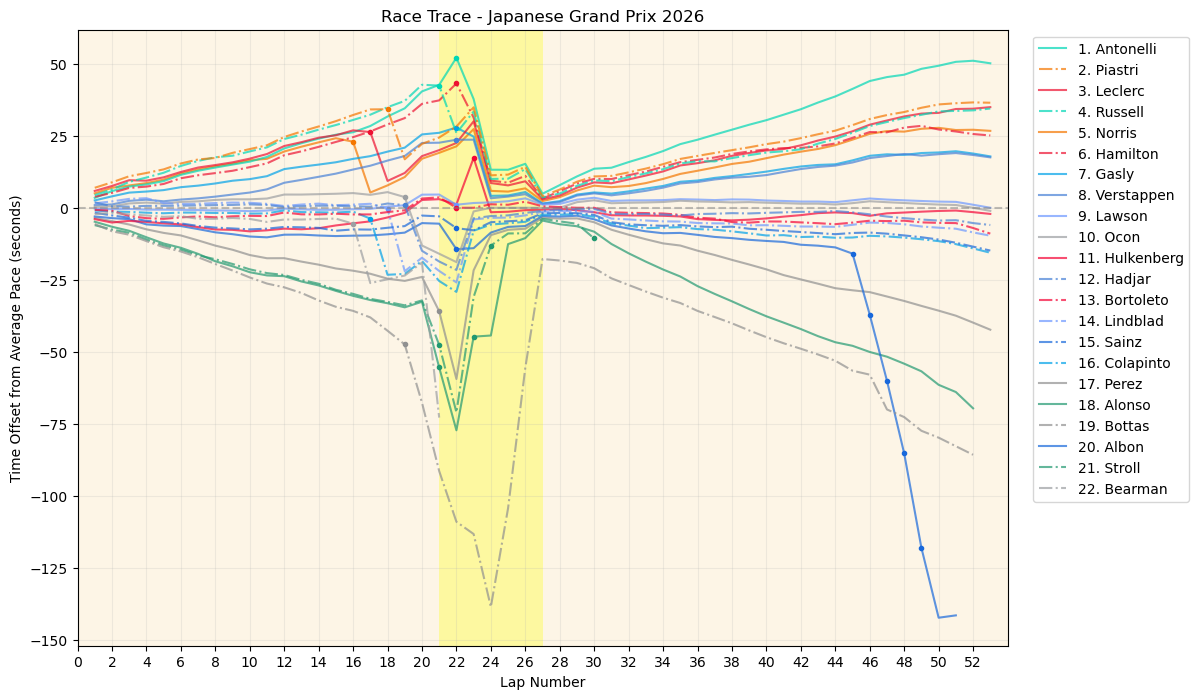

In [12]:
# Plot the time offsets for each driver
plt.figure(figsize=(12, 8))
plt.gca().set_facecolor("oldlace")
#plt.gcf().patch.set_facecolor("oldlace")
for d in driver_numbers:
    plt.plot(lap_numbers, driver_offsets[d], label=f"{driver_info[d][1]}. {driver_info[d][0]}", color='#' + driver_info[d][2], linestyle=driver_info[d][3], alpha=0.7)
    for pit_lap in driver_pit_laps[d]:
        plt.plot(pit_lap, driver_offsets[d][int(pit_lap)-1], 'o', color='#' + driver_info[d][2], markersize=3)
plt.axhline(0, color='gray', linestyle='--', alpha=0.5)
# Highlight safety car periods with yellow shaded regions
for sc_lap in safety_car_lap_numbers:
    plt.axvspan(sc_lap - 1, sc_lap + 0, color='yellow', alpha=0.3, linewidth=0)
plt.xlim(0, max(lap_numbers)+1)
plt.xticks(np.arange(0, max(lap_numbers)+1, 2))
plt.xlabel('Lap Number')
plt.ylabel('Time Offset from Average Pace (seconds)')
plt.title('Race Trace - Japanese Grand Prix 2026')
# sort the legend by driver position
handles, labels = plt.gca().get_legend_handles_labels()
sorted_handles_labels = sorted(zip(handles, labels), key=lambda x: int(x[1].split('.')[0]))
sorted_handles, sorted_labels = zip(*sorted_handles_labels)
plt.legend(sorted_handles, sorted_labels, bbox_to_anchor=(1.02, 1), loc='upper left')
plt.grid(alpha=0.2)
plt.show()

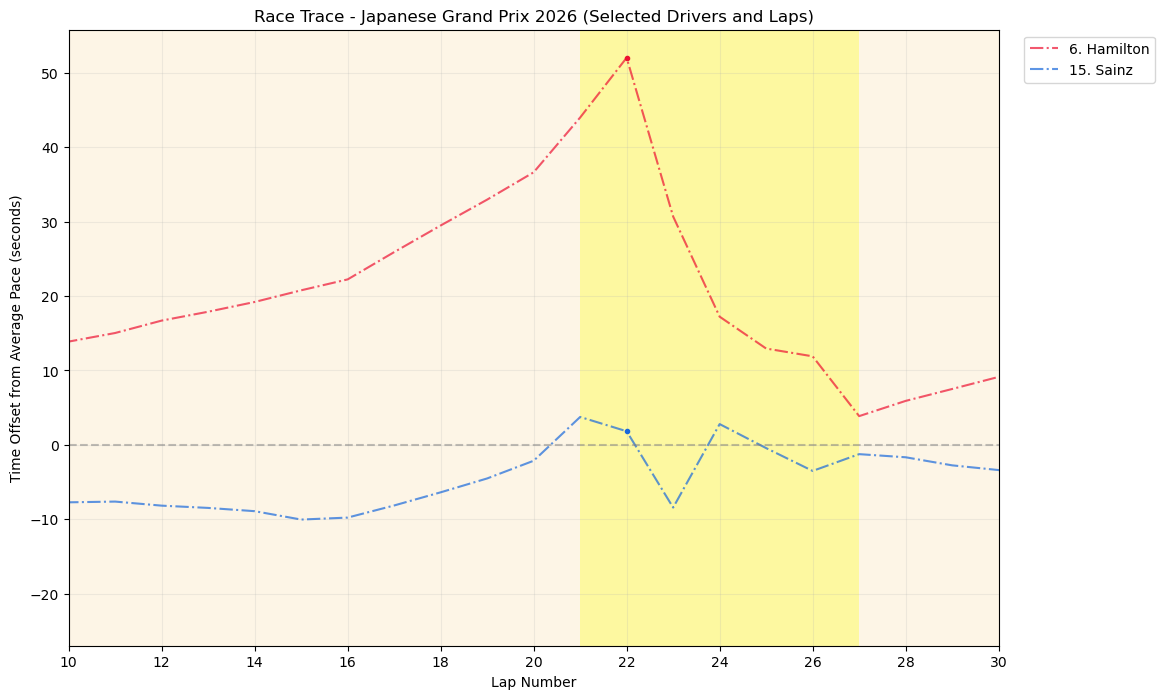

In [147]:
# plot only specific drivers and lap ranges
drivers_to_plot = ['44', '55']  # Example driver numbers
lap_range = (10, 30)  # Example lap range
plt.figure(figsize=(12, 8))
plt.gca().set_facecolor("oldlace")
for d in drivers_to_plot:
    plt.plot(lap_numbers, driver_offsets[d], label=f"{driver_info[d][1]}. {driver_info[d][0]}", color='#' + driver_info[d][2], linestyle=driver_info[d][3], alpha=0.7)
    for pit_lap in driver_pit_laps[d]:
        if lap_range[0] <= pit_lap <= lap_range[1]:
            plt.plot(pit_lap, driver_offsets[d][int(pit_lap)-1], 'o', color='#' + driver_info[d][2], markersize=3)
plt.axhline(0, color='gray', linestyle='--', alpha=0.5)
# Highlight safety car periods with yellow shaded regions
for sc_lap in safety_car_lap_numbers:
    if lap_range[0] <= sc_lap <= lap_range[1]:
        plt.axvspan(sc_lap - 1, sc_lap + 0, color='yellow', alpha=0.3, linewidth=0)
plt.xlim(lap_range)
plt.xticks(np.arange(lap_range[0], lap_range[1]+1, 2))
plt.xlabel('Lap Number')
plt.ylabel('Time Offset from Average Pace (seconds)')
plt.title('Race Trace - Japanese Grand Prix 2026 (Selected Drivers and Laps)')
handles, labels = plt.gca().get_legend_handles_labels()
sorted_handles_labels = sorted(zip(handles, labels), key=lambda x: int(x[1].split('.')[0]))
sorted_handles, sorted_labels = zip(*sorted_handles_labels)
plt.legend(sorted_handles, sorted_labels, bbox_to_anchor=(1.02, 1), loc='upper left')
plt.grid(alpha=0.2)
plt.show()